<a href="https://colab.research.google.com/github/marsznatalia/PodstawyUczeniaMaszynowego/blob/Class3/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [ ]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

<ipython-input-2-9f69f8392d9a>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


100%|██████████| 18.9k/18.9k [00:00<00:00, 18.7MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [ ]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

Zbuduj model benchmarkowy - zwykłą regresję liniową




In [ ]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
regressor = LinearRegression().fit(X_train, y_train)
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

evs = explained_variance_score(y_test, y_pred)
print(f"Explained Variance Score: {evs:.2f}")



Mean Squared Error (MSE): 252493731.92
Mean Absolute Error (MAE): 11377.18
Explained Variance Score: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data

,feature,VIF
0,Age,15.191310
1,Gender,2.059767
2,Education Level,2.403316
3,Job Title,4.865563
4,Years of Experience,9.479247


wysoka współliniowość dla age i years of experience
umiarkowana dla gender, education level, job title

Spróbuj poprawić wynik używając regresji LASSO

In [ ]:
lasso_regressor = Lasso(alpha=0.1)
lasso_regressor.fit(X_train, y_train)
y_pred_lasso = lasso_regressor.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Mean Squared Error (MSE) - Lasso: {mse_lasso:.2f}")

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"Mean Absolute Error (MAE) - Lasso: {mae_lasso:.2f}")

evs_lasso = explained_variance_score(y_test, y_pred_lasso)
print(f"Explained Variance Score - Lasso: {evs_lasso:.2f}")


Mean Squared Error (MSE) - Lasso: 252494271.29
Mean Absolute Error (MAE) - Lasso: 11377.18
Explained Variance Score - Lasso: 0.89


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [ ]:
df['YearsExperienceSquared'] = df['Years of Experience'] ** 2

y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

regressor = LinearRegression().fit(X_train, y_train)
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) z nową zmienną: {mse:.2f}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE) z nową zmienną: {mae:.2f}")

evs = explained_variance_score(y_test, y_pred)
print(f"Explained Variance Score z nową zmienną: {evs:.2f}")


Mean Squared Error (MSE) z nową zmienną: 253420055.95
Mean Absolute Error (MAE) z nową zmienną: 11266.85
Explained Variance Score z nową zmienną: 0.89


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

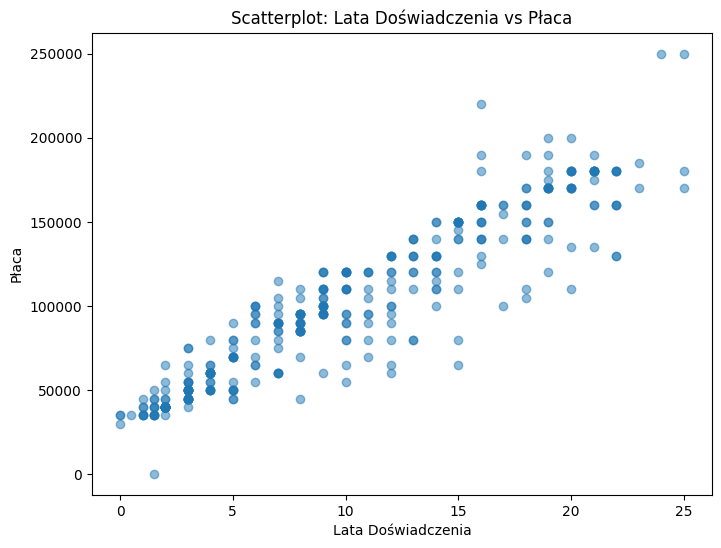

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.5)
plt.xlabel('Lata Doświadczenia')
plt.ylabel('Płaca')
plt.title('Scatterplot: Lata Doświadczenia vs Płaca')
plt.show()

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)
y_pred_knn = knn_regressor.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
print(f"Mean Squared Error (MSE) - K-NN: {mse_knn:.2f}")

mae_knn = mean_absolute_error(y_test, y_pred_knn)
print(f"Mean Absolute Error (MAE) - K-NN: {mae_knn:.2f}")

evs_knn = explained_variance_score(y_test, y_pred_knn)
print(f"Explained Variance Score - K-NN: {evs_knn:.2f}")


Mean Squared Error (MSE) - K-NN: 318410022.32
Mean Absolute Error (MAE) - K-NN: 12041.52
Explained Variance Score - K-NN: 0.86
